# Project 02 — Order Flow Imbalance as a Signal (BTCUSDT)

Building on notebook 01 (which chose **dollar bars** as the sampling scheme), this notebook builds
the **Order Flow Imbalance (OFI)** feature from the top-of-book and asks two questions:

1. **Contemporaneous** — does OFI explain the price move *within* the same bar? (Cont, Kukanov &
   Stoikov 2014 show a strong linear price-impact relation; this is our sanity check that the feed
   and the OFI computation are correct.)
2. **Predictive** — does OFI in bar *t* predict the return of bar *t+1*? This is the honest, hard
   question; on a liquid instrument we expect most of the signal to be contemporaneous, not
   predictive.

Data window: 2024-03-01..03 (matches notebook 01). `aggTrades` -> dollar bars; `bookTicker` ->
per-update OFI aggregated into each bar. OFI lives in `lib.features.order_flow_imbalance`.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "lib").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
PROJ = ROOT / "projects" / "02_crypto_microstructure_ofi"
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(PROJ / "src"))

from lib.bars import build_bars
from lib.features import order_flow_imbalance, depth_imbalance
from dataset import load_trades, load_book, book_day_paths

plt.rcParams["figure.figsize"] = (10, 4)
PLOTS = PROJ / "plots"; PLOTS.mkdir(exist_ok=True)
START, END = "2024-03-01", "2024-03-03" 

## 1. Price bars (dollar bars, chosen in notebook 01)

In [2]:
trades = load_trades("BTCUSDT", START, END)
# ~5-min-equivalent bar count, dollar-sampled
total_dollar = float((trades["price"] * trades["qty"]).sum())
bars = build_bars(trades, "dollar", threshold=total_dollar / 864)
print(f"{len(trades):,} trades -> {len(bars):,} dollar bars")
bars[["open", "close", "volume", "n_ticks", "buy_volume"]].head(3)

3,241,295 trades -> 864 dollar bars


,open,close,volume,n_ticks,buy_volume
t_close,,,,,
2024-03-01 00:02:40.540000+00:00,61203.4,61217.2,773.576,3642,392.010
2024-03-01 00:09:18.719000+00:00,61217.1,61393.4,772.094,5367,498.510
2024-03-01 00:17:22.334000+00:00,61393.3,61414.6,773.640,6131,326.643


## 2. Order Flow Imbalance per bar

For every top-of-book update we compute `e_n` (Cont et al.), then sum it over the book updates that
fall inside each bar. We also attach mean spread and mean depth imbalance per bar.

In [3]:
# bookTicker is ~30M rows/day, so we never load all days at once: process each day's
# partition and accumulate per-bar OFI into the global (3-day) bar grid.
bar_close = bars.index.to_numpy()
ofi  = np.zeros(len(bars)); sp_s = np.zeros(len(bars))
di_s = np.zeros(len(bars)); cnt  = np.zeros(len(bars))
n_updates = 0

for f in book_day_paths("BTCUSDT", START, END):
    book = pd.read_parquet(f, columns=["ts", "bid_px", "bid_qty", "ask_px", "ask_qty", "spread"])
    e  = order_flow_imbalance(book).to_numpy()
    di = depth_imbalance(book["bid_qty"], book["ask_qty"]).to_numpy()
    sp = book["spread"].to_numpy()
    idx = np.searchsorted(bar_close, book["ts"].to_numpy(), side="left")
    valid = idx < len(bars); gi = idx[valid]
    np.add.at(ofi,  gi, e[valid]);  np.add.at(sp_s, gi, sp[valid])
    np.add.at(di_s, gi, di[valid]); np.add.at(cnt,  gi, 1.0)
    n_updates += len(book)
    del book, e, di, sp, idx, valid, gi

print(f"{n_updates:,} book updates processed (day-by-day)")
cnt_safe = np.where(cnt > 0, cnt, 1.0)
bars["ofi"] = ofi
bars["spread_mean"] = sp_s / cnt_safe
bars["depth_imb"] = di_s / cnt_safe
bars["book_updates"] = cnt.astype(int)
bars["ret"] = np.log(bars["close"]).diff()
bars[["ofi", "spread_mean", "depth_imb", "book_updates", "ret"]].describe().round(5)

97,476,305 book updates processed (day-by-day)


,ofi,spread_mean,depth_imb,book_updates,ret
count,864.00000,864.00000,864.00000,864.00000,863.00000
mean,44.06827,0.13482,0.00619,112819.74769,0.00004
std,937.64525,0.19886,0.11787,61887.98837,0.00137
min,-3335.52100,0.10064,-0.41646,1727.00000,-0.00335
25%,-520.17300,0.10522,-0.07322,64768.75000,-0.00095
50%,56.35850,0.10881,0.00502,105697.00000,0.00007
75%,629.25575,0.11631,0.07654,152929.50000,0.00113
max,3251.33500,3.50730,0.48581,348582.00000,0.00424


## 3. Contemporaneous price impact (sanity check)

Regress the **same-bar** return on OFI. Cont et al. predict a strong, roughly linear relation — if
this R² is high and the slope positive, our OFI is wired correctly.

contemporaneous:  slope(lambda)=1.111e-06   R^2=0.579   n=863


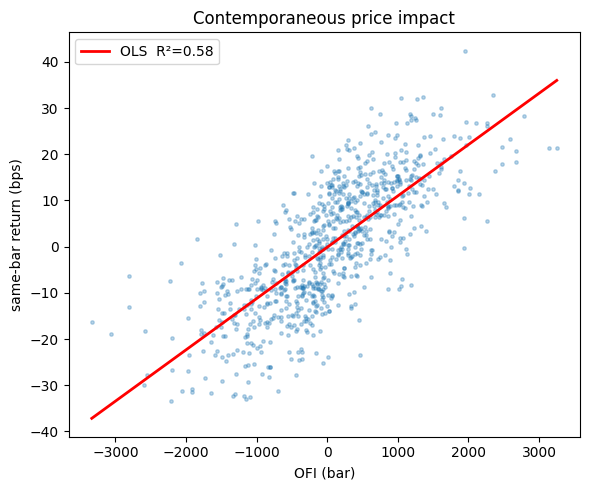

In [4]:
d = bars.dropna(subset=["ret", "ofi"])
x, y = d["ofi"].to_numpy(), d["ret"].to_numpy()
slope, intercept = np.polyfit(x, y, 1)
r2 = np.corrcoef(x, y)[0, 1] ** 2
print(f"contemporaneous:  slope(lambda)={slope:.3e}   R^2={r2:.3f}   n={len(d)}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(x, y * 1e4, s=6, alpha=0.3)
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, (slope * xs + intercept) * 1e4, "r-", lw=2, label=f"OLS  R²={r2:.2f}")
ax.set(xlabel="OFI (bar)", ylabel="same-bar return (bps)", title="Contemporaneous price impact")
ax.legend(); plt.tight_layout()
plt.savefig(PLOTS / "02_ofi_contemporaneous.png", dpi=110, bbox_inches="tight"); plt.show()

## 4. Is OFI predictive of the next bar?

The real test: regress **next-bar** return on this bar's OFI, and look at the correlation across a
few horizons. On a liquid venue we expect this to be small (most impact is immediate) and possibly
slightly negative (mean reversion / over-shoot correction).

corr(OFI_t, ret_{t+h}):
  h=0: +0.7612 (contemporaneous)
  h=1: -0.0263 (predictive)
  h=2: -0.0179 (predictive)
  h=3: +0.0131 (predictive)
  h=5: +0.0478 (predictive)


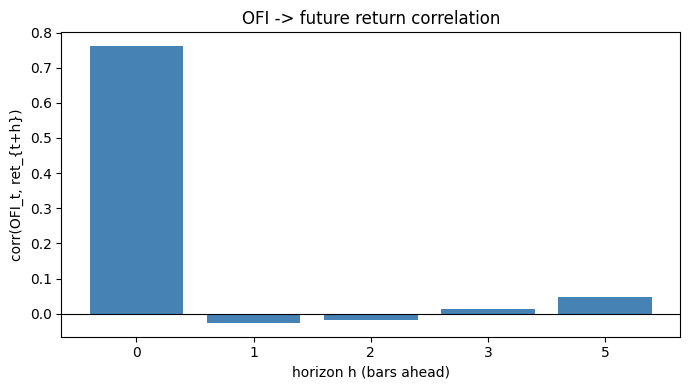

In [5]:
# standardized OFI for interpretable correlations
z = (d["ofi"] - d["ofi"].mean()) / d["ofi"].std()
r = d["ret"]
horizons = [0, 1, 2, 3, 5]
corr = {h: float(z.corr(r.shift(-h))) for h in horizons}
print("corr(OFI_t, ret_{t+h}):")
for h, c in corr.items():
    tag = "(contemporaneous)" if h == 0 else "(predictive)"
    print(f"  h={h}: {c:+.4f} {tag}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar([str(h) for h in horizons], [corr[h] for h in horizons], color="steelblue")
ax.axhline(0, color="k", lw=0.8)
ax.set(xlabel="horizon h (bars ahead)", ylabel="corr(OFI_t, ret_{t+h})",
       title="OFI -> future return correlation")
plt.tight_layout()
plt.savefig(PLOTS / "02_ofi_predictive.png", dpi=110, bbox_inches="tight"); plt.show()

## 5. Persist features for the labeling notebook (03)

In [6]:
feat_dir = PROJ / "data" / "features"; feat_dir.mkdir(parents=True, exist_ok=True)
out = feat_dir / f"BTCUSDT_dollarbars_{START}_{END}.parquet"
cols = ["t_open", "open", "high", "low", "close", "volume", "buy_volume",
        "n_ticks", "ofi", "spread_mean", "depth_imb", "book_updates", "ret"]
bars.reset_index()[["t_close"] + cols].to_parquet(out, index=False)
print("saved:", out.relative_to(ROOT), "  rows:", len(bars))

saved: projects\02_crypto_microstructure_ofi\data\features\BTCUSDT_dollarbars_2024-03-01_2024-03-03.parquet   rows: 864


## 6. Findings (BTCUSDT, 2024-03-01..03, 864 dollar bars)

- **OFI is wired correctly.** Contemporaneous OFI -> same-bar return: **R^2 = 0.58**, corr **+0.76**,
  positive slope (price impact lambda ~ 1.1e-6 return per OFI unit). This reproduces the Cont,
  Kukanov & Stoikov (2014) price-impact relation — strong validation of the feature and the feed.
- **OFI is NOT predictive.** corr(OFI_t, ret_{t+1}) = **-0.026** (and -0.018, +0.013, +0.048 at
  h=2,3,5) — all essentially zero, with a faint mean-reversion sign at h=1. The ~0.76 contemporaneous
  correlation collapses to noise one bar ahead.
- **Interpretation:** on a deeply liquid venue, OFI is a *descriptor* of the move happening **now**,
  not a *predictor* of the next move. The information is already in the price by the time the bar
  closes — exactly what efficient-market microstructure predicts at this latency.
- **Honesty for the portfolio:** this is the expected, correct result, not a failure. A naive
  backtest that trades on contemporaneous OFI would look amazing and be pure look-ahead leakage; the
  predictive test is the one that matters, and it says "no edge here at the bar-close horizon".
- Processed **97.5M book updates day-by-day** to stay within RAM (the production pattern).
- **Next (notebook 03):** triple-barrier labels + purged K-fold CV on the saved feature table
  (`data/features/BTCUSDT_dollarbars_2024-03-01_2024-03-03.parquet`) to test predictability properly,
  with sample weights and deflated Sharpe — does *any* combination of OFI + spread + depth-imbalance
  survive leakage-free validation?